# Unpaired BRAM grid: `mark_bram` threshold sweep, 11x11 + baseline (Experiment A)

The same 11x11 `(bw_in, bw_out)` grid as `../bram_grid_paired/`, but with the
default unpaired BRAM emission, at the loose 5 ns target on `xczu7ev`. Produces
`sweep_metrics.csv`, per-metric heatmaps, and the LUT-vs-BRAM Pareto front
(`pareto_lut_bram.png`). `exhaustive_search_metrics.csv` is the canonical copy
of the measured results cited by the thesis tables.

**To run:** edit the config cell below — `VIVADO_SETTINGS`, `CHECKPOINT`, and
the dataset paths. About 3 h wall-clock at 3 concurrent Vivado jobs.

In [1]:
import os
os.environ.setdefault('KERAS_BACKEND', 'jax')
os.environ.setdefault('XLA_PYTHON_CLIENT_MEM_FRACTION', '0.5')

import sys
from pathlib import Path

# ---- USER KNOBS --------------------------------------------------------------
CHECKPOINT_PATH = Path(
    '../../../models/jsc_plf/64-16/'
    'epoch=4433-val_acc=0.817-ebops=40646-val_loss=0.534.keras'
)
PARTICLES         = 64
FEATURES          = 16
PART_NAME         = 'xczu7ev-ffvc1156-2-e'
MODEL_NAME        = 'jsc'           # used as Verilog top module and Vivado project name
CLOCK_PERIOD      = 5.0             # ns; matches the existing grid sweep
CLOCK_UNCERTAINTY = 0.0
LATENCY_CUTOFF    = 3.1          # ns; IR pipelining stage budget
TRACE_BATCH       = 2048            # trace_minmax batch (25600 OOMs at N=64)
MAX_VIVADO_PAR    = 3               # concurrent Vivado processes
VIVADO_SETTINGS   = '/tools/Xilinx/2025.1/Vivado/settings64.sh'

# Grid axes. 11 × 11 = 121 grid points + 'none' baseline = 122 Vivado runs.
BWIN_VALUES  = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
BWOUT_VALUES = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
INCLUDE_NONE = True                 # also build the no-mark_bram baseline
RUN_VIVADO   = True                 # set False to write RTL only
# -----------------------------------------------------------------------------

HGQ_JSC150 = Path('..').resolve()  # shared helpers: model.py, data.py, dump_bram.tcl
DATA_DIR   = Path('../../../dataset/jsc_plf').resolve()  # from prepare_datasets.sh
NB_DIR     = Path('.').resolve()

if str(HGQ_JSC150) not in sys.path:
    sys.path.insert(0, str(HGQ_JSC150))

def folder_for(bwin, bwout):
    if bwin is None and bwout is None:
        return 'none'
    return f'bwin_{bwin}_bwout_{bwout}'

grid_points = [(bi, bo) for bi in BWIN_VALUES for bo in BWOUT_VALUES]
if INCLUDE_NONE:
    grid_points.append((None, None))

print(f'Checkpoint     : {CHECKPOINT_PATH}')
print(f'N x F          : {PARTICLES} x {FEATURES}')
print(f'Grid           : {len(BWIN_VALUES)} x {len(BWOUT_VALUES)} + none = {len(grid_points)} points')
print(f'Part / clock   : {PART_NAME}, T={CLOCK_PERIOD} ns -> {round(1000.0 / CLOCK_PERIOD, 1)} MHz target')
print(f'Output dir     : {NB_DIR}')

Checkpoint     : /home/kevin/Dev/Imperial/HGQ-LUT-AE/models/jsc_plf/64-16/epoch=4433-val_acc=0.817-ebops=40646-val_loss=0.534.keras
N x F          : 64 x 16
Grid           : 11 x 11 + none = 122 points
Part / clock   : xczu7ev-ffvc1156-2-e, T=5.0 ns -> 200.0 MHz target
Output dir     : /home/kevin/Dev/Imperial/HGQ2-examples/jsc150/exhaustive_search


Load the checkpoint; `trace_minmax` ranges are computed once and cached.

In [6]:
import keras
from model import SameDim0   # harmless to include even though this ckpt doesn't use it
from data import get_data
from hgq.utils import trace_minmax

raw_ckpt = CHECKPOINT_PATH.expanduser().resolve()
if not raw_ckpt.exists():
    raise FileNotFoundError(f'CHECKPOINT_PATH not found: {raw_ckpt}')

# Cache the post-trace_minmax version next to the raw Pareto file so we only
# pay the trace_minmax cost once.
traced_ckpt = raw_ckpt.parent / f'model_traced_n{PARTICLES}_f{FEATURES}.keras'

if not traced_ckpt.exists():
    print(f'Raw checkpoint   : {raw_ckpt}')
    print('No cached traced checkpoint — running trace_minmax over train + val...')
    model_raw = keras.models.load_model(raw_ckpt, compile=False, custom_objects={'SameDim0': SameDim0})
    (X_train, _), (X_val, _), _ = get_data(DATA_DIR, PARTICLES, FEATURES == 3)
    trace_minmax(model_raw, X_train, batch_size=TRACE_BATCH, reset=True,  verbose=True)
    trace_minmax(model_raw, X_val,   batch_size=TRACE_BATCH, reset=False, verbose=True)
    model_raw.save(traced_ckpt)
    print(f'Cached traced checkpoint to: {traced_ckpt}')
else:
    print(f'Using cached traced checkpoint: {traced_ckpt}')

model = keras.models.load_model(traced_ckpt, compile=False, custom_objects={'SameDim0': SameDim0})
in_shape = model.input_shape
model_N  = in_shape[1] if len(in_shape) > 2 else 1
model_F  = in_shape[-1]
print(f'Loaded model: N={model_N} F={model_F} layers={[l.__class__.__name__ for l in model.layers]}')
assert model_N == PARTICLES, f'checkpoint N={model_N} != PARTICLES={PARTICLES}'
assert model_F == FEATURES,  f'checkpoint F={model_F} != FEATURES={FEATURES}'

Using cached traced checkpoint: /home/kevin/Dev/Imperial/HGQ-LUT-AE/models/jsc_plf/64-16/model_traced_n64_f16.keras
Loaded model: N=64 F=16 layers=['InputLayer', 'QDenseT', 'QSum', 'QDenseT', 'QDenseT', 'QAdd', 'QSum', 'QDenseT', 'QDenseT']


Trace once; per-point predicates are applied on the IR.

In [7]:
from collections import Counter
from da4ml.converter import trace_model
from da4ml.trace import HWConfig, comb_trace, mark_bram
from da4ml.types import minimal_kif

HW_CONFIG      = HWConfig(1, -1, -1)
SOLVER_OPTIONS = {'hard_dc': 2}

OPCODE_NAMES = {
    -1: 'passthrough', 0: 'vadd', 1: 'vsub', 2: 'relu', 3: 'wrap',
    4: 'cadd', 5: 'const', 6: 'msb_mux', 7: 'vmul', 8: 'lookup',
}

print('Running trace_model + comb_trace (once, for all grid points)...')
inp, out = trace_model(model, hwconf=HW_CONFIG, solver_options=SOLVER_OPTIONS, verbose=True)
comb_base = comb_trace(inp, out)
print('Trace complete.')

hist = Counter(op.opcode for op in comb_base.ops)
print('\nBaseline opcode histogram:')
for code in sorted(hist):
    print(f'  opcode {code:>3} ({OPCODE_NAMES.get(code, "?"):>12s}) : {hist[code]:>6d}')
n_lookup = hist.get(8, 0)
print(f'\nTotal lookup ops to be sweep-marked : {n_lookup}')

# Bw_in / bw_out distribution of the lookup ops — gives a sense of where the
# grid thresholds matter most.
bwins  = Counter()
bwouts = Counter()
for op in comb_base.ops:
    if op.opcode != 8:
        continue
    bw_in  = sum(minimal_kif(comb_base.ops[op.id0].qint)) if op.id0 >= 0 else 0
    bw_out = sum(minimal_kif(op.qint))
    bwins[bw_in]   += 1
    bwouts[bw_out] += 1
print('\nLookup-op bw_in distribution :', dict(sorted(bwins.items())))
print('Lookup-op bw_out distribution :', dict(sorted(bwouts.items())))

Running trace_model + comb_trace (once, for all grid points)...
Loading DAIS tracer plugin from hgq._dais_tracer.main:HGQ2DAISTracer.
q_dense_t (QDenseT) cumcost: 20850.800000000003, latency: 5.0
q_sum (QSum) cumcost: 21665.600000000002, latency: 10.0
q_dense_t_1 (QDenseT) cumcost: 28011.800000000003, latency: 8.0
q_dense_t_2 (QDenseT) cumcost: 22484.6, latency: 15.0
q_add (QAdd) cumcost: 35432.6, latency: 16.0
q_sum_1 (QSum) cumcost: 40176.6, latency: 22.0
q_dense_t_3 (QDenseT) cumcost: 44336.2, latency: 28.0
q_dense_t_4 (QDenseT) cumcost: 46065.4, latency: 33.0
Trace complete.

Baseline opcode histogram:
  opcode  -1 ( passthrough) :    660
  opcode   0 (        vadd) :   4233
  opcode   3 (        wrap) :   7057
  opcode   4 (        cadd) :   5305
  opcode   8 (      lookup) :   3819

Total lookup ops to be sweep-marked : 3819

Lookup-op bw_in distribution : {1: 56, 2: 295, 3: 474, 4: 865, 5: 928, 6: 626, 7: 358, 8: 168, 9: 41, 10: 4, 11: 2, 12: 2}
Lookup-op bw_out distribution : {

Write an RTL project per grid point.

In [8]:
from da4ml.codegen import RTLModel

model_stem = raw_ckpt.stem  # epoch=4433-val_acc=...

for bwin, bwout in grid_points:
    folder_name = folder_for(bwin, bwout)
    out_path = NB_DIR / folder_name / model_stem
    out_path.mkdir(parents=True, exist_ok=True)

    if bwin is None and bwout is None:
        comb = comb_base
    else:
        t_in  = bwin  if bwin  is not None else 0
        t_out = bwout if bwout is not None else 0
        comb = mark_bram(
            comb_base,
            predicate=lambda bw_in, bw_out, ti=t_in, to=t_out: (bw_in >= ti) and (bw_out >= to),
            latency_cutoff=LATENCY_CUTOFF,
        )

    rtl = RTLModel(
        comb,
        MODEL_NAME,
        str(out_path),
        latency_cutoff=LATENCY_CUTOFF,
        clock_period=CLOCK_PERIOD,
        part_name=PART_NAME,
        clock_uncertainty=CLOCK_UNCERTAINTY,
    )
    rtl.write()
    print(f'{folder_name:<22s}  ->  {out_path}')

print(f'\nWrote {len(grid_points)} project(s).')

bwin_0_bwout_0          ->  /home/kevin/Dev/Imperial/HGQ2-examples/jsc150/exhaustive_search/bwin_0_bwout_0/epoch=4433-val_acc=0.817-ebops=40646-val_loss=0.534
bwin_0_bwout_1          ->  /home/kevin/Dev/Imperial/HGQ2-examples/jsc150/exhaustive_search/bwin_0_bwout_1/epoch=4433-val_acc=0.817-ebops=40646-val_loss=0.534
bwin_0_bwout_2          ->  /home/kevin/Dev/Imperial/HGQ2-examples/jsc150/exhaustive_search/bwin_0_bwout_2/epoch=4433-val_acc=0.817-ebops=40646-val_loss=0.534
bwin_0_bwout_3          ->  /home/kevin/Dev/Imperial/HGQ2-examples/jsc150/exhaustive_search/bwin_0_bwout_3/epoch=4433-val_acc=0.817-ebops=40646-val_loss=0.534
bwin_0_bwout_4          ->  /home/kevin/Dev/Imperial/HGQ2-examples/jsc150/exhaustive_search/bwin_0_bwout_4/epoch=4433-val_acc=0.817-ebops=40646-val_loss=0.534
bwin_0_bwout_5          ->  /home/kevin/Dev/Imperial/HGQ2-examples/jsc150/exhaustive_search/bwin_0_bwout_5/epoch=4433-val_acc=0.817-ebops=40646-val_loss=0.534
bwin_0_bwout_6          ->  /home/kevin/Dev/Im

Run Vivado on every project, 3 concurrent.

In [9]:
import shlex
import subprocess
import time
from collections import deque

def start_vivado_job(tcl_path):
    run_dir = tcl_path.parent
    out_f = open(run_dir / 'vivado_stdout.log', 'w')
    err_f = open(run_dir / 'vivado_stderr.log', 'w')
    bash_cmd = (
        f'set -e\n'
        f'source {shlex.quote(VIVADO_SETTINGS)}\n'
        f'vivado -mode batch -source {shlex.quote(str(tcl_path.resolve()))}\n'
    )
    proc = subprocess.Popen(
        ['bash', '-lc', bash_cmd], cwd=str(run_dir),
        stdout=out_f, stderr=err_f, text=True,
    )
    return dict(tcl_path=tcl_path, run_dir=run_dir, proc=proc,
                out_f=out_f, err_f=err_f, start_time=time.time())

if RUN_VIVADO:
    tcl_paths = sorted(NB_DIR.glob('*/*/build_vivado_prj.tcl'))
    print(f'Found {len(tcl_paths)} Vivado project(s) to build.')

    queue = deque(tcl_paths)
    running, done = [], []

    def drain():
        while queue and len(running) < MAX_VIVADO_PAR:
            j = start_vivado_job(queue.popleft())
            running.append(j)
            tag = f'{j["run_dir"].parent.name}/{j["run_dir"].name}'
            print(f'[START]  {tag}  pid={j["proc"].pid}')

    drain()
    while running:
        time.sleep(1.0)
        for j in list(running):
            rc = j['proc'].poll()
            if rc is None:
                continue
            j['out_f'].close()
            j['err_f'].close()
            dt = time.time() - j['start_time']
            tag = f'{j["run_dir"].parent.name}/{j["run_dir"].name}'
            status = 'OK' if rc == 0 else f'FAIL(rc={rc})'
            print(f'[{status}] {tag}  t={dt:.1f}s')
            done.append(dict(tag=tag, rc=rc, elapsed=dt))
            running.remove(j)
            drain()

    bad = [d['tag'] for d in done if d['rc'] != 0]
    print(f'\n==== Vivado done {len(done)}/{len(tcl_paths)}; failures: {bad or "none"} ====')
else:
    print('RUN_VIVADO=False -- skipping Vivado launch.')

Found 122 Vivado project(s) to build.
[START]  bwin_0_bwout_0/epoch=4433-val_acc=0.817-ebops=40646-val_loss=0.534  pid=525654
[START]  bwin_0_bwout_1/epoch=4433-val_acc=0.817-ebops=40646-val_loss=0.534  pid=525655
[START]  bwin_0_bwout_10/epoch=4433-val_acc=0.817-ebops=40646-val_loss=0.534  pid=525657
[FAIL(rc=1)] bwin_0_bwout_1/epoch=4433-val_acc=0.817-ebops=40646-val_loss=0.534  t=343.0s
[START]  bwin_0_bwout_2/epoch=4433-val_acc=0.817-ebops=40646-val_loss=0.534  pid=590934
[FAIL(rc=1)] bwin_0_bwout_0/epoch=4433-val_acc=0.817-ebops=40646-val_loss=0.534  t=348.0s
[START]  bwin_0_bwout_3/epoch=4433-val_acc=0.817-ebops=40646-val_loss=0.534  pid=592996
[OK] bwin_0_bwout_10/epoch=4433-val_acc=0.817-ebops=40646-val_loss=0.534  t=357.0s
[START]  bwin_0_bwout_4/epoch=4433-val_acc=0.817-ebops=40646-val_loss=0.534  pid=595455
[FAIL(rc=1)] bwin_0_bwout_3/epoch=4433-val_acc=0.817-ebops=40646-val_loss=0.534  t=255.0s
[START]  bwin_0_bwout_5/epoch=4433-val_acc=0.817-ebops=40646-val_loss=0.534  pid

Parse post-route reports into `sweep_metrics.csv` and plot the heatmaps.

In [15]:
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pat_block = re.compile(r'\blookup_table_block\b')
pat_plain = re.compile(r'\blookup_table\b')
pat_stage = re.compile(r'jsc_stage(\d+)\.v$')

def util_pct(text, label):
    m = re.search(
        r'^\|\s*' + re.escape(label) + r'\s*\|[^|]*\|[^|]*\|[^|]*\|[^|]*\|\s*([\d.]+)\s*\|',
        text, re.MULTILINE,
    )
    return float(m.group(1)) if m else float('nan')

def util_used(text, label):
    m = re.search(
        r'^\|\s*' + re.escape(label) + r'\s*\|\s*([\d.]+)\s*\|',
        text, re.MULTILINE,
    )
    return float(m.group(1)) if m else float('nan')

def parse_timing(text):
    # Vivado timing report has multiple `WNS(ns)` sections; the first one is
    # the design-level summary. The header line continues with TNS(ns),
    # WHS(ns), ... after `WNS(ns)`, and the separator below it has multiple
    # dash-runs separated by spaces — so [^\n]* is needed on both lines.
    m = re.search(r'WNS\(ns\)[^\n]*\n[^\n]*\n\s*([-\d.]+)', text)
    wns = float(m.group(1)) if m else None
    achieved = (CLOCK_PERIOD - wns) if wns is not None else None
    fmax = (1000.0 / achieved) if achieved and achieved > 0 else None
    return wns, achieved, fmax

rows = []
for bwin, bwout in grid_points:
    folder_name = folder_for(bwin, bwout)
    src_dirs   = list(NB_DIR.glob(f'{folder_name}/{model_stem}/src'))
    rpt_paths  = list(NB_DIR.glob(f'{folder_name}/{model_stem}/output_jsc/reports/jsc_post_route_util.rpt'))
    tim_paths  = list(NB_DIR.glob(f'{folder_name}/{model_stem}/output_jsc/reports/jsc_post_route_timing.rpt'))
    meta_paths = list(NB_DIR.glob(f'{folder_name}/{model_stem}/metadata.json'))

    n_block = n_plain = n_stages = 0
    if src_dirs:
        for vf in sorted(src_dirs[0].glob('jsc_stage*.v')):
            t = vf.read_text()
            n_block += len(pat_block.findall(t))
            n_plain += len(pat_plain.findall(t))
        n_stages = sum(1 for vf in src_dirs[0].glob('jsc_stage*.v') if pat_stage.search(vf.name))

    latency_cycles = float('nan')
    if meta_paths:
        try:
            latency_cycles = json.loads(meta_paths[0].read_text()).get('latency', float('nan'))
        except (json.JSONDecodeError, OSError):
            pass

    util = {k: float('nan') for k in (
        'clb_lut_pct', 'lut_logic_pct', 'lut_mem_pct', 'bram_pct',
        'clb_ff_pct', 'dsp_pct',
        'lut_used', 'lut_logic_used', 'lut_mem_used',
        'ff_used', 'ramb18_used', 'ramb36_used', 'bram_tile_used', 'dsp_used',
    )}
    wns = achieved = fmax = None
    if rpt_paths:
        text = rpt_paths[0].read_text()
        util['clb_lut_pct']    = util_pct(text, 'CLB LUTs')
        util['lut_logic_pct']  = util_pct(text, 'LUT as Logic')
        util['lut_mem_pct']    = util_pct(text, 'LUT as Memory')
        util['bram_pct']       = util_pct(text, 'Block RAM Tile')
        util['clb_ff_pct']     = util_pct(text, 'CLB Registers')
        util['dsp_pct']        = util_pct(text, 'DSPs')
        util['lut_used']       = util_used(text, 'CLB LUTs')
        util['lut_logic_used'] = util_used(text, 'LUT as Logic')
        util['lut_mem_used']   = util_used(text, 'LUT as Memory')
        util['ff_used']        = util_used(text, 'CLB Registers')
        util['ramb18_used']    = util_used(text, 'RAMB18')
        util['ramb36_used']    = util_used(text, 'RAMB36/FIFO*')
        util['bram_tile_used'] = util_used(text, 'Block RAM Tile')
        util['dsp_used']       = util_used(text, 'DSPs')
    if tim_paths:
        wns, achieved, fmax = parse_timing(tim_paths[0].read_text())

    lat_ns = (latency_cycles * achieved) if (achieved is not None and not np.isnan(latency_cycles)) else float('nan')
    rows.append({
        'folder': folder_name,
        'bwin': bwin if bwin is not None else 'none',
        'bwout': bwout if bwout is not None else 'none',
        'lookup_table': n_plain,
        'lookup_table_block': n_block,
        'n_stages': n_stages,
        'latency_cycles': latency_cycles,
        'latency_ns': lat_ns,
        'WNS_ns': wns if wns is not None else float('nan'),
        'Fmax_MHz': fmax if fmax is not None else float('nan'),
        **util,
    })

df = pd.DataFrame(rows).set_index('folder').sort_index()
if df['Fmax_MHz'].notna().any():
    df.to_csv(NB_DIR / 'sweep_metrics.csv')
else:
    # No Vivado reports on disk: keep the committed results instead of clobbering them.
    df = pd.read_csv(NB_DIR / 'sweep_metrics.csv', index_col='folder')
    print('no Vivado reports found; loaded committed sweep_metrics.csv')
print(f'Parsed {len(df)} grid points; saved sweep_metrics.csv')
df.head(8)

Parsed 122 grid points; saved sweep_metrics.csv


,bwin,bwout,lookup_table,lookup_table_block,n_stages,latency_cycles,latency_ns,WNS_ns,Fmax_MHz,clb_lut_pct,...,clb_ff_pct,dsp_pct,lut_used,lut_logic_used,lut_mem_used,ff_used,ramb18_used,ramb36_used,bram_tile_used,dsp_used
folder,,,,,,,,,,,,,,,,,,,,,
bwin_0_bwout_0,0,0,0,3819,39,35,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bwin_0_bwout_1,0,1,0,3819,39,35,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bwin_0_bwout_10,0,10,3898,43,25,18,70.650,1.075,254.777070,15.51,...,5.95,0.0,35727.0,34080.0,1647.0,27406.0,32.0,1.0,17.0,0.0
bwin_0_bwout_2,0,2,725,3094,36,34,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bwin_0_bwout_3,0,3,1682,2137,36,35,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bwin_0_bwout_4,0,4,2447,1372,37,34,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bwin_0_bwout_5,0,5,3031,797,33,29,134.850,0.350,215.053763,13.35,...,6.90,0.0,30753.0,27758.0,2995.0,31776.0,605.0,2.0,304.5,0.0
bwin_0_bwout_6,0,6,3343,478,33,29,131.834,0.454,219.973603,13.70,...,6.61,0.0,31573.0,28877.0,2696.0,30474.0,377.0,2.0,190.5,0.0


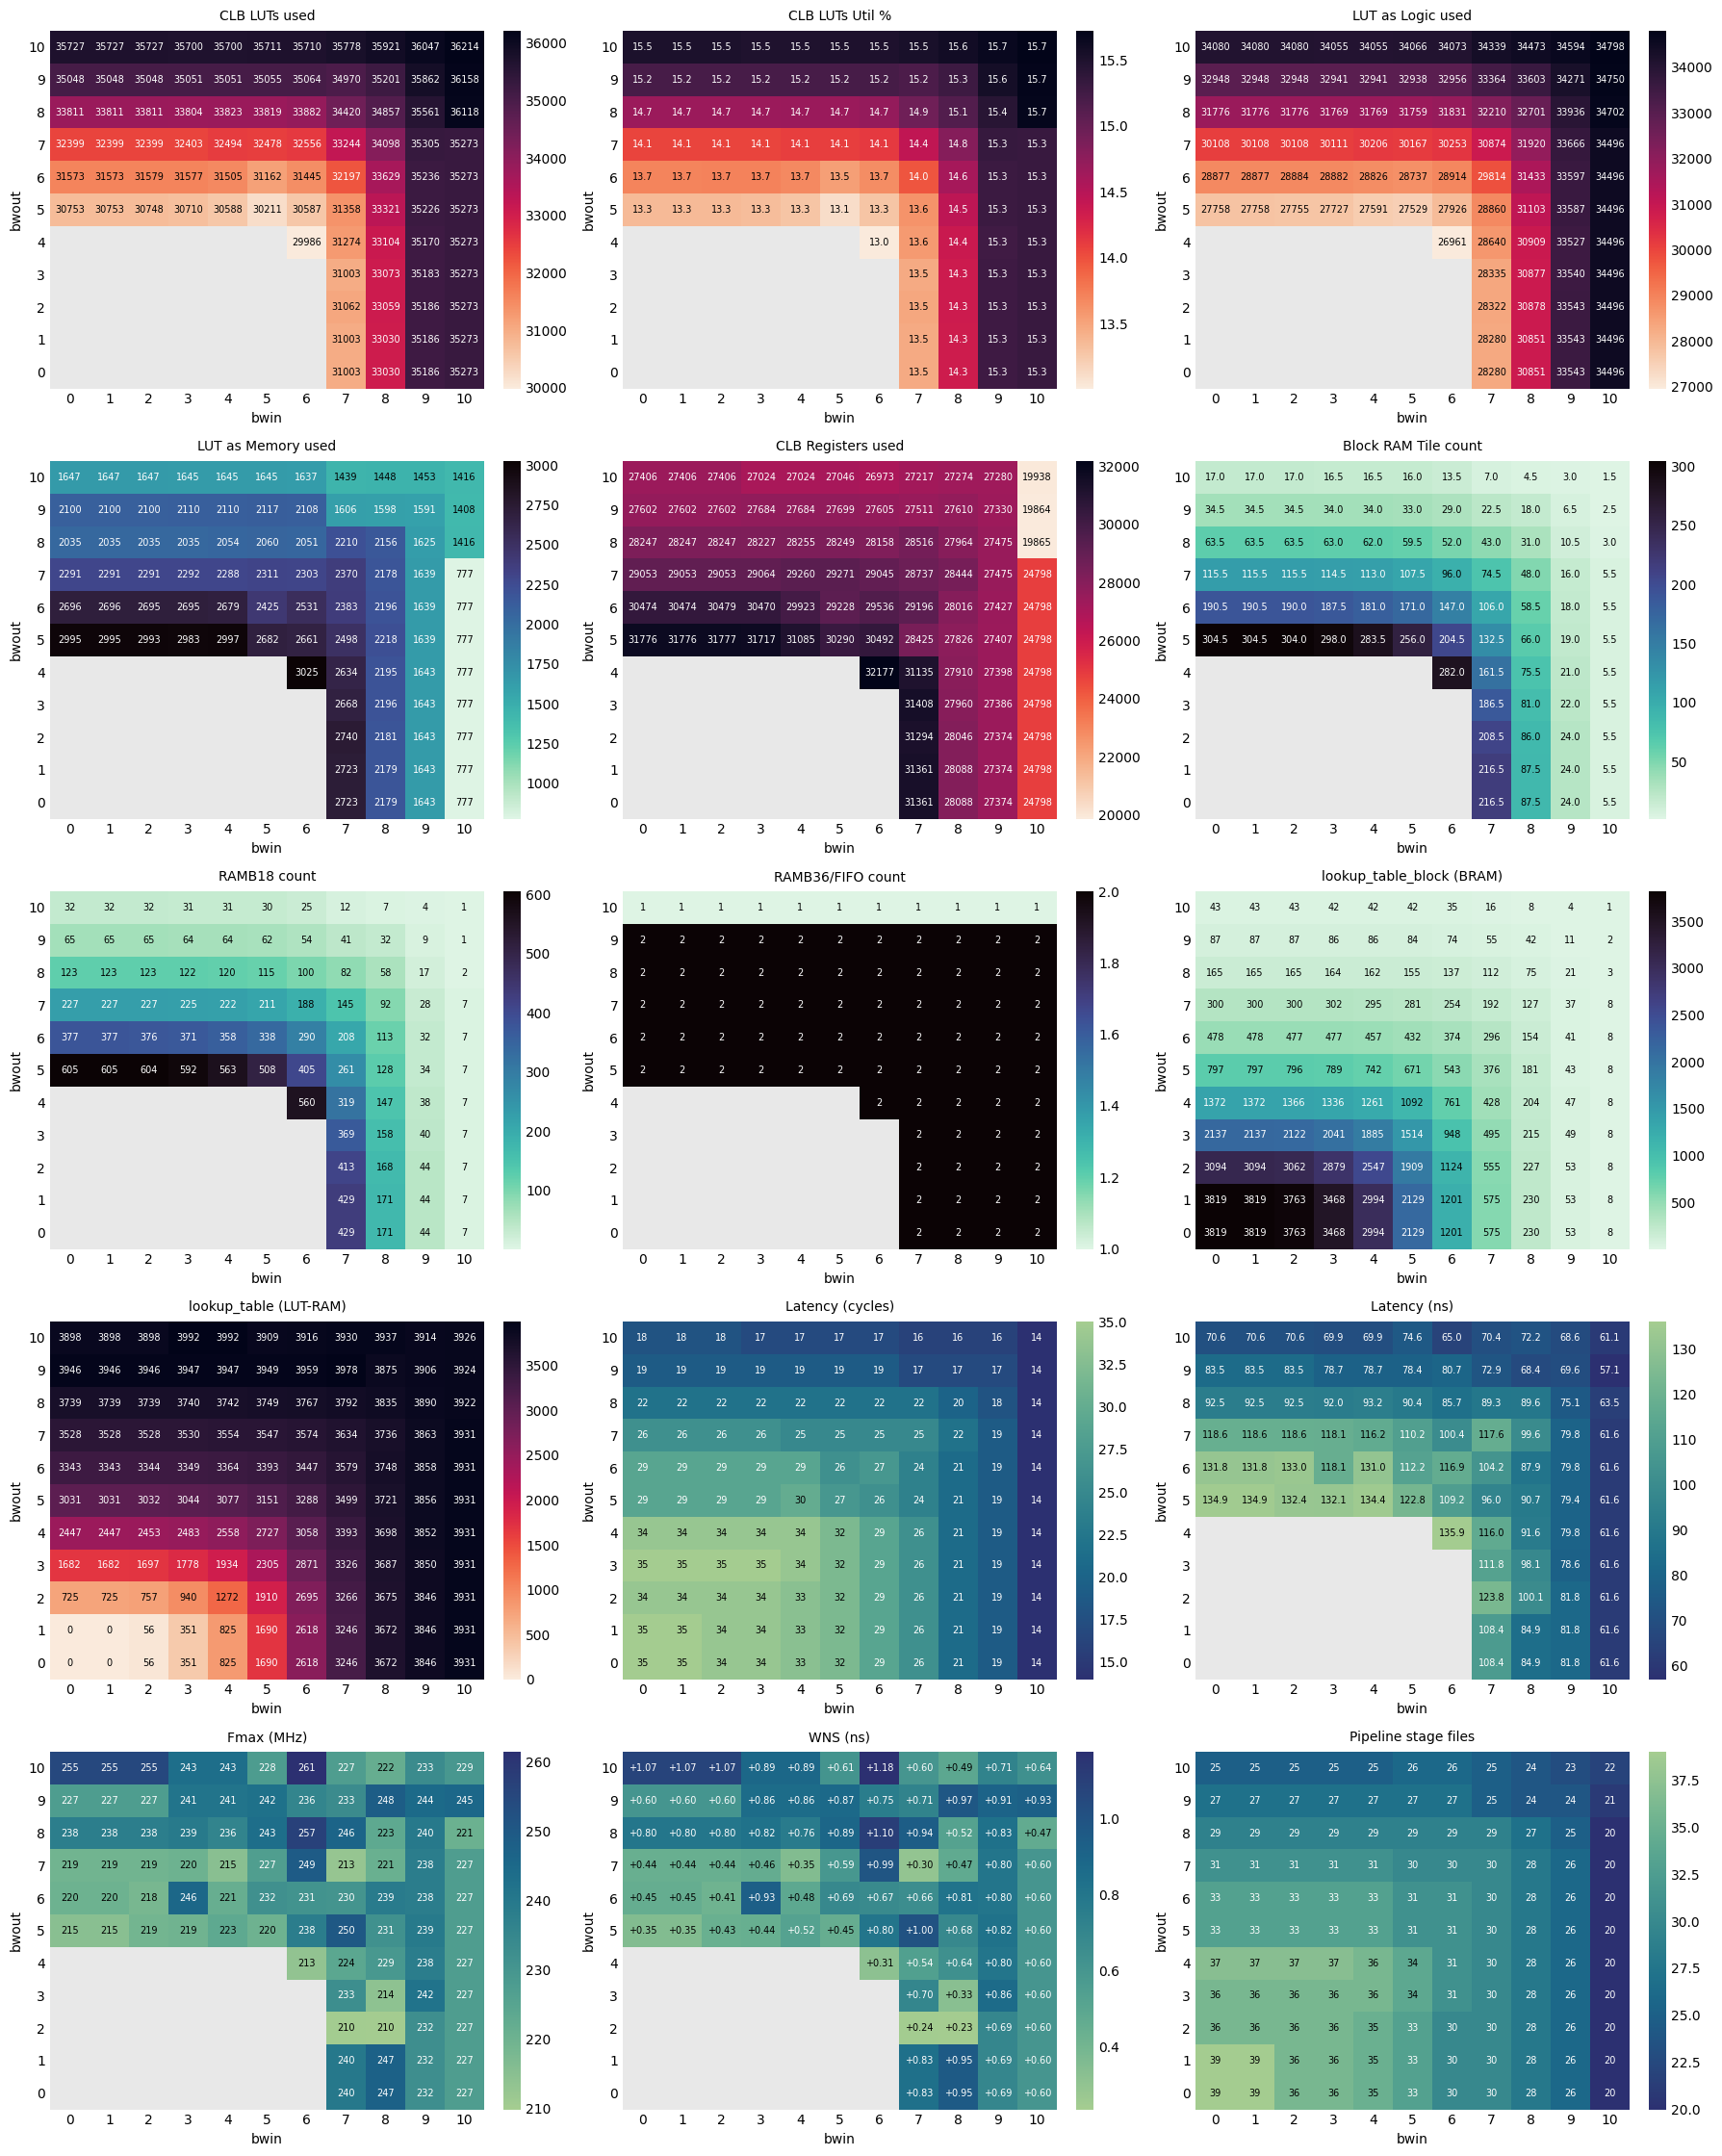

Saved heatmaps to /home/kevin/Dev/Imperial/HGQ2-examples/jsc150/exhaustive_search/sweep_heatmaps.png


In [16]:
import matplotlib as mpl

df_grid = df[(df['bwin'] != 'none') & (df['bwout'] != 'none')].copy()
df_grid['bwin']  = df_grid['bwin'].astype(int)
df_grid['bwout'] = df_grid['bwout'].astype(int)

metrics = [
    ('lut_used',           'CLB LUTs used',             '{:.0f}', 'rocket_r'),
    ('clb_lut_pct',        'CLB LUTs Util %',           '{:.1f}', 'rocket_r'),
    ('lut_logic_used',     'LUT as Logic used',         '{:.0f}', 'rocket_r'),
    ('lut_mem_used',       'LUT as Memory used',        '{:.0f}', 'mako_r'),
    ('ff_used',            'CLB Registers used',        '{:.0f}', 'rocket_r'),
    ('bram_tile_used',     'Block RAM Tile count',      '{:.1f}', 'mako_r'),
    ('ramb18_used',        'RAMB18 count',              '{:.0f}', 'mako_r'),
    ('ramb36_used',        'RAMB36/FIFO count',         '{:.0f}', 'mako_r'),
    ('lookup_table_block', 'lookup_table_block (BRAM)', '{:.0f}', 'mako_r'),
    ('lookup_table',       'lookup_table (LUT-RAM)',    '{:.0f}', 'rocket_r'),
    ('latency_cycles',     'Latency (cycles)',          '{:.0f}', 'crest_r'),
    ('latency_ns',         'Latency (ns)',              '{:.1f}', 'crest_r'),
    ('Fmax_MHz',           'Fmax (MHz)',                '{:.0f}', 'crest'),
    ('WNS_ns',             'WNS (ns)',                  '{:+.2f}', 'crest'),
    ('n_stages',           'Pipeline stage files',      '{:.0f}', 'crest_r'),
]

n_metrics = len(metrics)
n_cols    = 3
n_rows    = (n_metrics + n_cols - 1) // n_cols

def text_color(value, norm, cmap):
    """Pick black/white text based on background luminance for readability."""
    r, g, b, _ = cmap(norm(value))
    lum = 0.299 * r + 0.587 * g + 0.114 * b
    return 'black' if lum > 0.55 else 'white'

plt.rcParams.update({'font.family': 'DejaVu Sans', 'axes.titlesize': 10})

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.0 * n_cols, 4.5 * n_rows))
axes = axes.flatten()

for ax, (col, title, fmt, cmap_name) in zip(axes, metrics):
    pivot = df_grid.pivot(index='bwout', columns='bwin', values=col).sort_index(ascending=False)
    vals  = pivot.values.astype(float)

    try:
        import seaborn as sns
        cmap = sns.color_palette(cmap_name, as_cmap=True)
    except (ImportError, ValueError):
        cmap = mpl.colormaps['cividis']  # perceptually uniform, colour-blind safe

    finite = vals[np.isfinite(vals)]
    vmin, vmax = (finite.min(), finite.max()) if finite.size else (0, 1)
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

    cmap = cmap.copy()
    cmap.set_bad('#e8e8e8')  # soft grey for NaN instead of harsh blank

    im = ax.imshow(np.ma.masked_invalid(vals), aspect='auto', origin='upper',
                   cmap=cmap, norm=norm)
    ax.set_title(title, pad=8, weight='medium')
    ax.set_xlabel('bwin'); ax.set_ylabel('bwout')
    ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)));   ax.set_yticklabels(pivot.index)
    ax.tick_params(length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)

    for i in range(vals.shape[0]):
        for j in range(vals.shape[1]):
            v = vals[i, j]
            if not np.isfinite(v):
                continue
            try:    txt = fmt.format(v)
            except (TypeError, ValueError): txt = str(v)
            ax.text(j, i, txt, ha='center', va='center',
                    color=text_color(v, norm, cmap), fontsize=7)

    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.outline.set_visible(False)
    cb.ax.tick_params(length=0)

for ax in axes[n_metrics:]:
    ax.axis('off')

plt.tight_layout()
plt.savefig(NB_DIR / 'sweep_heatmaps.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved heatmaps to {NB_DIR / "sweep_heatmaps.png"}')

LUT-vs-BRAM and LUT-vs-latency Pareto fronts.

Pareto front: minimise LUT, minimise BRAM tiles
  folder                  bwin bwout     LUT   BRAM  cycles      ns   Fmax
  bwin_6_bwout_4             6     4   29986  282.0      29     nan    nan
  bwin_5_bwout_5             5     5   30211  256.0      27     nan    nan
  bwin_6_bwout_5             6     5   30587  204.5      26     nan    nan
  bwin_7_bwout_3             7     3   31003  186.5      26     nan    nan
  bwin_5_bwout_6             5     6   31162  171.0      26     nan    nan
  bwin_7_bwout_4             7     4   31274  161.5      26     nan    nan
  bwin_7_bwout_5             7     5   31358  132.5      24     nan    nan
  bwin_7_bwout_6             7     6   32197  106.0      24     nan    nan
  bwin_6_bwout_7             6     7   32556   96.0      25     nan    nan
  bwin_8_bwout_0             8     0   33030   87.5      21     nan    nan
  bwin_8_bwout_2             8     2   33059   86.0      21     nan    nan
  bwin_8_bwout_3             8     3   33073   81.0 

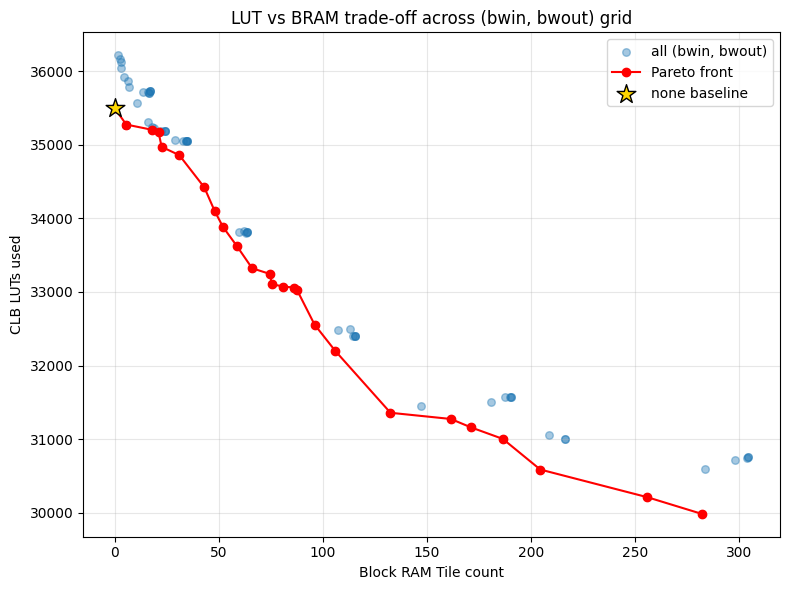


Saved Pareto plot to /home/kevin/Dev/Imperial/HGQ2-examples/jsc150/exhaustive_search/pareto_lut_bram.png


In [12]:
def pareto_front(rows, minimise_x, minimise_y):
    sorted_rows = sorted(rows, key=lambda r: (r[minimise_x], r[minimise_y]))
    front, best_y = [], float('inf')
    for r in sorted_rows:
        if r[minimise_y] < best_y:
            front.append(r)
            best_y = r[minimise_y]
    return front

valid = df.dropna(subset=['lut_used', 'bram_tile_used'])
rows_v = valid.reset_index().to_dict('records')

# LUT vs BRAM tiles — minimise both.
front_lut_bram = pareto_front(rows_v, 'lut_used', 'bram_tile_used')
print('Pareto front: minimise LUT, minimise BRAM tiles')
print(f'  {"folder":<22s} {"bwin":>5s} {"bwout":>5s} {"LUT":>7s} {"BRAM":>6s} {"cycles":>7s} {"ns":>7s} {"Fmax":>6s}')
for r in front_lut_bram:
    print(f'  {r["folder"]:<22s} {str(r["bwin"]):>5s} {str(r["bwout"]):>5s}'
          f' {r["lut_used"]:>7.0f} {r["bram_tile_used"]:>6.1f}'
          f' {r["latency_cycles"]:>7.0f} {r["latency_ns"]:>7.1f}'
          f' {r["Fmax_MHz"]:>6.0f}')

# LUT vs latency_ns — minimise both.
valid_lat = valid.dropna(subset=['latency_ns']).reset_index().to_dict('records')
front_lut_lat = pareto_front(valid_lat, 'lut_used', 'latency_ns')
print('\nPareto front: minimise LUT, minimise latency (ns)')
print(f'  {"folder":<22s} {"bwin":>5s} {"bwout":>5s} {"LUT":>7s} {"BRAM":>6s} {"cycles":>7s} {"ns":>7s} {"Fmax":>6s}')
for r in front_lut_lat:
    print(f'  {r["folder"]:<22s} {str(r["bwin"]):>5s} {str(r["bwout"]):>5s}'
          f' {r["lut_used"]:>7.0f} {r["bram_tile_used"]:>6.1f}'
          f' {r["latency_cycles"]:>7.0f} {r["latency_ns"]:>7.1f}'
          f' {r["Fmax_MHz"]:>6.0f}')

# Scatter plot: LUT vs BRAM tiles, all points + Pareto highlight + baseline.
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(valid['bram_tile_used'], valid['lut_used'], alpha=0.4, s=30, label='all (bwin, bwout)')
front_x = [r['bram_tile_used'] for r in front_lut_bram]
front_y = [r['lut_used']       for r in front_lut_bram]
ax.plot(front_x, front_y, '-o', color='red', label='Pareto front')
if 'none' in df.index:
    base = df.loc['none']
    ax.scatter([base['bram_tile_used']], [base['lut_used']], marker='*', s=200,
               color='gold', edgecolor='k', label='none baseline', zorder=5)
ax.set_xlabel('Block RAM Tile count')
ax.set_ylabel('CLB LUTs used')
ax.set_title('LUT vs BRAM trade-off across (bwin, bwout) grid')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(NB_DIR / 'pareto_lut_bram.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'\nSaved Pareto plot to {NB_DIR / "pareto_lut_bram.png"}')

Per-BRAM fill histogram for one operating point.

Demo folder : /home/kevin/Dev/Imperial/HGQ2-examples/jsc150/exhaustive_search/bwin_7_bwout_5/epoch=4433-val_acc=0.817-ebops=40646-val_loss=0.534
lookup_table_block instances in Verilog : 376
[dump_bram] running on jsc_post_route.dcp ...
BRAM cells (post-route)                : 263   (82 dual-port, 181 single-port)
BRAM cells with known capacity         : 263

Fill-% distribution stats:
  count       : 263
  min / max   : 3.47%  /  222.22%
  mean        : 13.21%
  median      : 9.72%
  std (σ)     : 18.13%
  mean ± 1σ   : [ -4.92,  31.34]%
  mean ± 2σ   : [-23.05,  49.48]%
  fraction within ±1σ : 95.4%
  fraction within ±2σ : 98.1%


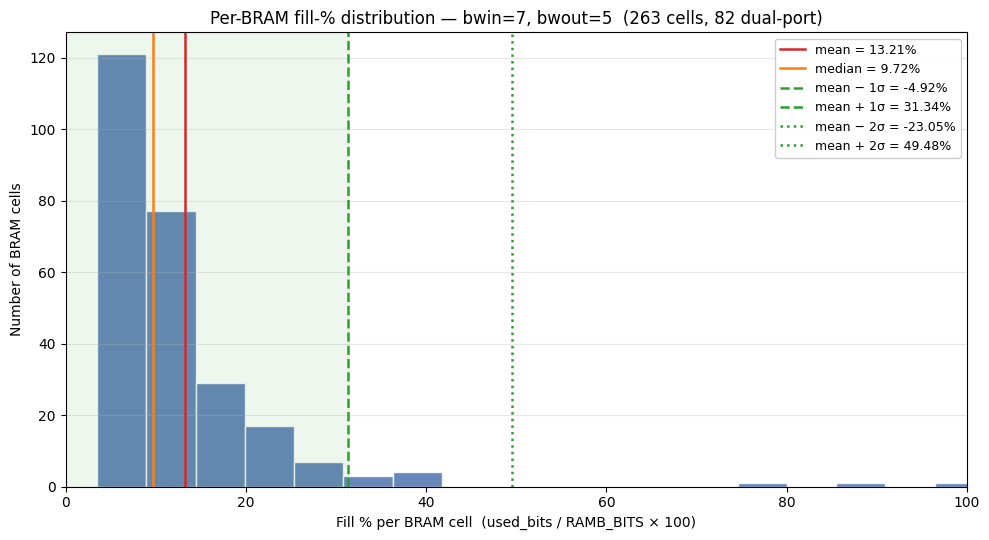


Saved histogram to /home/kevin/Dev/Imperial/HGQ2-examples/jsc150/exhaustive_search/fill_pct_hist_bwin7_bwout5.png


In [2]:
import re, shlex, subprocess
import numpy as np
import matplotlib.pyplot as plt

# ---- CONFIG: which folder to analyse ----------------------------------------
DEMO_BWIN, DEMO_BWOUT = 7, 5
DUMP_TCL = (Path('..').resolve() / 'dump_bram.tcl').resolve()
XILINX_SETTINGS = '/tools/Xilinx/2025.1/Vivado/settings64.sh'
FORCE_RERUN_DUMP = False    # set True to re-run dump_bram.tcl even if cache exists

# RAMB capacities (data + parity bits per primitive). Used to compute fill %.
RAMB_BITS = {
    'RAMB18E2': 16 * 1024 + 2 * 1024,
    'RAMB36E2': 32 * 1024 + 4 * 1024,
    'FIFO18E2': 16 * 1024 + 2 * 1024,
    'FIFO36E2': 32 * 1024 + 4 * 1024,
}

# ---- Helpers (compact subset of da4ml_grid/bram_grid_sweep.ipynb §5) --------
_lut_pat = re.compile(
    r'lookup_table_block\s*#\s*\(\s*(\d+)\s*,\s*(\d+)\s*,\s*"([^"]+)"\s*\)'
    r'\s*([A-Za-z_][\w$]*)'
)
_cell_name_pat = re.compile(r'(?:^|/)stage(\d+)/(op_\d+)(?:/|$)')

def parse_lookup_blocks(src_dir):
    """Each lookup_table_block in jsc_stage*.v -> dict with widths, stage, instance, used_bits."""
    out = []
    for vf in sorted(Path(src_dir).glob('jsc_stage*.v')):
        text = vf.read_text()
        m_stage = re.match(r'jsc_stage(\d+)\.v$', vf.name)
        stage_num = m_stage.group(1) if m_stage else None
        for m in _lut_pat.finditer(text):
            bw_in, bw_out, mem_file, inst = m.groups()
            bw_in, bw_out = int(bw_in), int(bw_out)
            out.append(dict(
                bw_in=bw_in, bw_out=bw_out, mem_file=mem_file,
                instance=inst, stage_num=stage_num,
                static_used_bits=(1 << bw_in) * bw_out,
            ))
    return out

def run_dump_bram(run_dir, force=False):
    """Invoke da4ml_grid/dump_bram.tcl on jsc_post_route.dcp; cache as dump_bram.txt."""
    run_dir = Path(run_dir)
    dcp = run_dir / 'output_jsc' / 'jsc_post_route.dcp'
    out = run_dir / 'dump_bram.txt'
    if not dcp.exists():
        raise FileNotFoundError(f'missing dcp: {dcp}')
    needs_run = force or not out.exists() or 'CELL|' not in out.read_text()
    if not needs_run:
        return out
    bash_cmd = (
        f'set -e\nsource {shlex.quote(XILINX_SETTINGS)}\n'
        f'vivado -mode batch -source {shlex.quote(str(DUMP_TCL))} '
        f'-tclargs {shlex.quote(str(dcp))} {shlex.quote(str(out))}\n'
    )
    print(f'[dump_bram] running on {dcp.name} ...')
    r = subprocess.run(['bash', '-lc', bash_cmd], cwd=str(run_dir),
                       capture_output=True, text=True)
    if r.returncode != 0:
        raise RuntimeError(f'dump_bram failed:\nSTDOUT:\n{r.stdout}\nSTDERR:\n{r.stderr}')
    return out

def parse_dump_bram(dump_path):
    """Parse dump_bram.txt → list of {name, ref, props}."""
    cells, cur = [], None
    for line in Path(dump_path).read_text().splitlines():
        if not line.strip():
            if cur is not None:
                cells.append(cur); cur = None
            continue
        if line.startswith('#'):
            continue
        if line.startswith('CELL|'):
            parts = line.split('|')
            cur = dict(name=parts[1], ref=parts[2], props={})
            for kv in parts[3:]:
                if '=' in kv:
                    k, v = kv.split('=', 1)
                    cur['props'][k] = v
    if cur is not None:
        cells.append(cur)
    return cells

def fill_pct_per_cell(blocks, cells):
    """For each BRAM cell, sum the static_used_bits of blocks mapped to it
    by hierarchical cell name (port A) + same-stage dual-port absorption
    (port B)."""
    # 1. Bucket blocks by (stage_num, op_instance) — keys we'll match against
    #    the Vivado cell names like 'stage<N>/op_<NN>/readout_reg'.
    block_idx = {}
    for i, blk in enumerate(blocks):
        if blk['stage_num'] is None:
            continue
        block_idx.setdefault((blk['stage_num'], blk['instance']), []).append(i)

    # 2. Primary mapping by cell name.
    mapping, by_stage_unmatched = {c['name']: [] for c in cells}, {}
    matched = set()
    for c in cells:
        m = _cell_name_pat.search(c['name'])
        if not m:
            continue
        for i in block_idx.get((m.group(1), m.group(2)), []):
            mapping[c['name']].append(i)
            matched.add(i)
    # 3. Pool of blocks not pointed to by any cell name — candidates for
    #    dual-port port-B absorption on a same-stage cell.
    for i in range(len(blocks)):
        if i in matched: continue
        if blocks[i]['stage_num'] is None: continue
        by_stage_unmatched.setdefault(blocks[i]['stage_num'], []).append(i)
    # 4. For each B_USED=1 cell, absorb one same-stage unmatched block.
    for c in cells:
        if c['props'].get('B_USED', '0') != '1':
            continue
        m = _cell_name_pat.search(c['name'])
        if not m:
            continue
        pool = by_stage_unmatched.get(m.group(1))
        if pool:
            mapping[c['name']].append(pool.pop(0))

    # 5. Compute fill %.
    fills = {}
    for c in cells:
        cap = RAMB_BITS.get(c['ref'])
        if cap is None:
            continue
        used = sum(blocks[i]['static_used_bits'] for i in mapping[c['name']])
        fills[c['name']] = 100.0 * used / cap
    return fills

# ---- Run for one demo folder -------------------------------------------------
demo_folder = NB_DIR / folder_for(DEMO_BWIN, DEMO_BWOUT)
inner = next(demo_folder.glob('epoch=*'), None)
assert inner is not None, f'no run dir under {demo_folder}'
print(f'Demo folder : {demo_folder}/{inner.name}')

blocks = parse_lookup_blocks(inner / 'src')
print(f'lookup_table_block instances in Verilog : {len(blocks)}')

dump_path = run_dump_bram(inner, force=FORCE_RERUN_DUMP)
cells = parse_dump_bram(dump_path)
n_dual = sum(1 for c in cells if c['props'].get('B_USED', '0') == '1')
print(f'BRAM cells (post-route)                : {len(cells)}'
      f'   ({n_dual} dual-port, {len(cells)-n_dual} single-port)')

fills = fill_pct_per_cell(blocks, cells)
values = np.array(list(fills.values()))
n_cells_with_cap = len(values)
print(f'BRAM cells with known capacity         : {n_cells_with_cap}')

# ---- Stats -------------------------------------------------------------------
mean   = values.mean()
median = np.median(values)
std    = values.std(ddof=0)
p_lo1, p_hi1 = mean - std,     mean + std
p_lo2, p_hi2 = mean - 2 * std, mean + 2 * std
print()
print('Fill-% distribution stats:')
print(f'  count       : {n_cells_with_cap}')
print(f'  min / max   : {values.min():.2f}%  /  {values.max():.2f}%')
print(f'  mean        : {mean:.2f}%')
print(f'  median      : {median:.2f}%')
print(f'  std (σ)     : {std:.2f}%')
print(f'  mean ± 1σ   : [{p_lo1:6.2f}, {p_hi1:6.2f}]%')
print(f'  mean ± 2σ   : [{p_lo2:6.2f}, {p_hi2:6.2f}]%')
print(f'  fraction within ±1σ : {((values >= p_lo1) & (values <= p_hi1)).mean() * 100:.1f}%')
print(f'  fraction within ±2σ : {((values >= p_lo2) & (values <= p_hi2)).mean() * 100:.1f}%')

# ---- Histogram with stat markers --------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.hist(values, bins=40, color='#4c72b0', edgecolor='white', alpha=0.85)

def _vline(x, color, ls, label):
    ax.axvline(x, color=color, linestyle=ls, linewidth=1.8, label=label)

_vline(mean,   '#d62728', '-',  f'mean = {mean:.2f}%')
_vline(median, '#ff7f0e', '-',  f'median = {median:.2f}%')
_vline(p_lo1,  '#2ca02c', '--', f'mean − 1σ = {p_lo1:.2f}%')
_vline(p_hi1,  '#2ca02c', '--', f'mean + 1σ = {p_hi1:.2f}%')
_vline(p_lo2,  '#2ca02c', ':',  f'mean − 2σ = {p_lo2:.2f}%')
_vline(p_hi2,  '#2ca02c', ':',  f'mean + 2σ = {p_hi2:.2f}%')

# Shaded ±1σ band for emphasis.
ax.axvspan(p_lo1, p_hi1, color='#2ca02c', alpha=0.08)

ax.set_xlabel('Fill % per BRAM cell  (used_bits / RAMB_BITS × 100)')
ax.set_ylabel('Number of BRAM cells')
ax.set_title(
    f'Per-BRAM fill-% distribution — bwin={DEMO_BWIN}, bwout={DEMO_BWOUT}  '
    f'({n_cells_with_cap} cells, {n_dual} dual-port)'
)
ax.set_xlim(0, max(100.0, p_hi2 + 5))
ax.grid(True, axis='y', alpha=0.3)
ax.legend(loc='upper right', fontsize=9, framealpha=0.95)
plt.tight_layout()
out_png = NB_DIR / f'fill_pct_hist_bwin{DEMO_BWIN}_bwout{DEMO_BWOUT}.png'
plt.savefig(out_png, dpi=130, bbox_inches='tight')
plt.show()
print(f'\nSaved histogram to {out_png}')

Power reports -> energy-per-inference heatmap.

In [ ]:
import re as _re_pow
import numpy as _np_pow

def _parse_power(rpt_path):
    """Return (total_W, dynamic_W, static_W). NaN if unreadable."""
    if not rpt_path.exists(): return float('nan'), float('nan'), float('nan')
    text = rpt_path.read_text()
    def _f(pat):
        m = _re_pow.search(pat, text)
        return float(m.group(1)) if m else float('nan')
    return (_f(r'Total On-Chip Power \(W\)\s*\|\s*([\d.]+)'),
            _f(r'Dynamic \(W\)\s*\|\s*([\d.]+)'),
            _f(r'Device Static \(W\)\s*\|\s*([\d.]+)'))

import matplotlib as _mpl
import matplotlib.pyplot as _plt
import pandas as _pd

rows = []
for prj_dir in sorted(NB_DIR.glob('*/*')):
    if not (prj_dir / 'output_jsc').exists(): continue
    folder = prj_dir.parent.name
    rpt = prj_dir / 'output_jsc' / 'reports' / 'jsc_post_route_power.rpt'
    total, dyn, static = _parse_power(rpt)
    drow = df[df.index == folder] if df.index.name == 'folder' else df[df['folder'] == folder] if 'folder' in df.columns else _pd.DataFrame()
    if drow.empty: continue
    drow = drow.iloc[0]
    fmax = drow.get('Fmax_MHz', drow.get('fmax_mhz', float('nan')))
    e_nJ = total * (1000.0 / fmax) if fmax == fmax and fmax > 0 and total == total else float('nan')
    rows.append(dict(folder=folder, bwin=drow.get('bwin'), bwout=drow.get('bwout'),
                     total_W=total, fmax_MHz=fmax, nJ_per_inf=e_nJ))

df_e = _pd.DataFrame(rows)
df_e.to_csv(NB_DIR / 'sweep_energy.csv', index=False)
print(f'Parsed power for {len(df_e)} runs')

# Plot 11x11 heatmap
df_grid = df_e[(df_e['bwin'] != 'none') & (df_e['bwout'] != 'none')].copy()
if not df_grid.empty:
    df_grid['bwin']  = df_grid['bwin'].astype(int)
    df_grid['bwout'] = df_grid['bwout'].astype(int)
    pivot = df_grid.pivot(index='bwout', columns='bwin', values='nJ_per_inf').sort_index(ascending=False)
    vals = pivot.values.astype(float)

    try:
        import seaborn as sns
        cmap = sns.color_palette('rocket_r', as_cmap=True).copy()
    except ImportError:
        cmap = _mpl.colormaps['inferno']
    cmap.set_bad('#e8e8e8')

    finite = vals[_np_pow.isfinite(vals)]
    fig, ax = _plt.subplots(figsize=(8, 6.5))
    if finite.size > 0:
        norm = _mpl.colors.Normalize(vmin=finite.min(), vmax=finite.max())
        im = ax.imshow(_np_pow.ma.masked_invalid(vals), aspect='auto', cmap=cmap, norm=norm)
        for i in range(vals.shape[0]):
            for j in range(vals.shape[1]):
                v = vals[i, j]
                if _np_pow.isfinite(v):
                    txt_col = 'white' if v > _np_pow.nanmedian(finite) else 'black'
                    ax.text(j, i, f'{v:.1f}', ha='center', va='center', color=txt_col, fontsize=8)
                else:
                    ax.text(j, i, '—', ha='center', va='center', color='#777', fontsize=9)
        ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
        ax.set_yticks(range(len(pivot.index)));   ax.set_yticklabels(pivot.index)
        ax.set_xlabel('bwin'); ax.set_ylabel('bwout')
        ax.set_title('Energy per inference (nJ/jet) — N=64 BRAM grid, xczu7ev, T=5 ns')
        cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04); cb.set_label('nJ/jet')
    _plt.tight_layout()
    _plt.savefig(NB_DIR / 'sweep_energy_heatmap.png', dpi=130, bbox_inches='tight')
    _plt.show()
    print(f'Saved {NB_DIR / "sweep_energy_heatmap.png"}')

# Also report the 'none' baseline for comparison
if 'none' in df_e['folder'].values:
    none_row = df_e[df_e['folder'] == 'none'].iloc[0]
    print(f'\nnone baseline (no mark_bram): {none_row["total_W"]:.2f} W, '
          f'{none_row["fmax_MHz"]:.1f} MHz, {none_row["nJ_per_inf"]:.2f} nJ/jet')

print('\n=== Lowest energy/jet (timing-met points only) ===')
ok = df_e[df_e['nJ_per_inf'].notna()].sort_values('nJ_per_inf').head(5)
print(ok[['folder','bwin','bwout','total_W','fmax_MHz','nJ_per_inf']].to_string(
    index=False, float_format='%.2f', na_rep='-'))
